In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Dataset
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')



In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Preprocess data
df = df.drop(columns=['customerID'])  # Remove customer ID column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df.select_dtypes(include=[np.number]).median(), inplace=True)  # Fill missing values only for numeric columns
df = pd.get_dummies(df, drop_first=True)  # Convert categorical variables to dummy variables

# Define features and target
X = df.drop(columns=['Churn_Yes'])  # Independent variables
y = df['Churn_Yes']  # Dependent variable (binary classification)


In [5]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [6]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



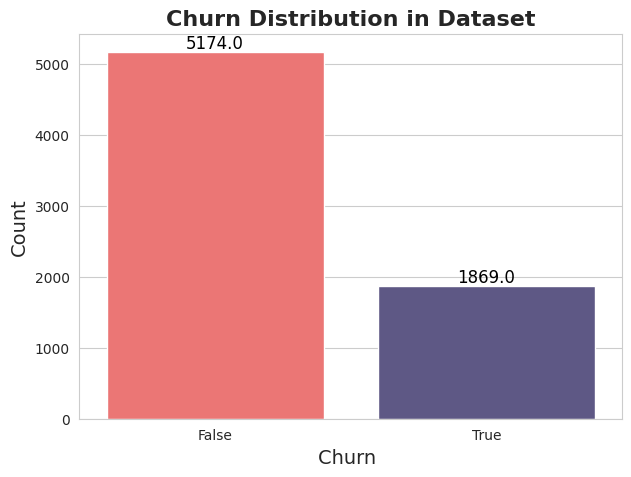

In [8]:
plt.figure(figsize=(7,5))
sns.set_style("whitegrid")
ax = sns.countplot(x=y, palette=['#ff6361', '#58508d'])

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=12, color='black')

plt.title("Churn Distribution in Dataset", fontsize=16, fontweight='bold')
plt.xlabel("Churn ", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.show()


In [9]:

# Logistic Regression from scratch
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.epochs):
            model = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(model)
            
            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
            db = (1 / n_samples) * np.sum(predictions - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict(self, X):
        model = np.dot(X, self.weights) + self.bias
        predictions = self.sigmoid(model)
        return [1 if i > 0.5 else 0 for i in predictions]



Logistic Regression from scratch accuracy: 0.7934705464868701


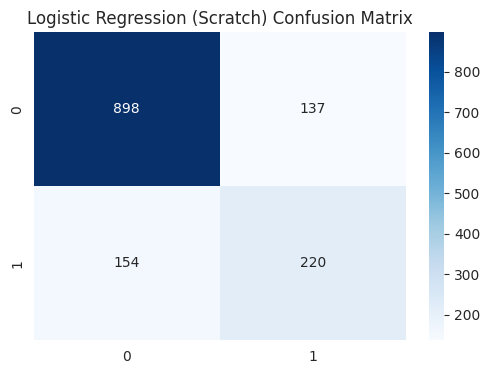

In [10]:
# Train and evaluate Logistic Regression from scratch
log_reg_scratch = LogisticRegressionScratch()
log_reg_scratch.fit(X_train_scaled, y_train)
y_pred_scratch = log_reg_scratch.predict(X_test_scaled)
print("Logistic Regression from scratch accuracy:", accuracy_score(y_test, y_pred_scratch))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_scratch), annot=True, cmap='Blues', fmt='d')
plt.title("Logistic Regression (Scratch) Confusion Matrix")
plt.show()


Logistic Regression (sklearn) accuracy: 0.8069552874378992


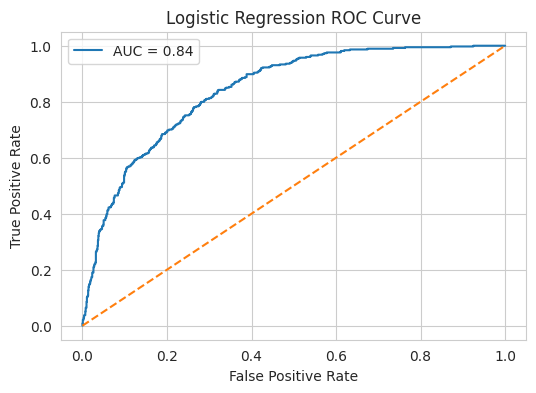

In [11]:
# Logistic Regression using sklearn
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression (sklearn) accuracy:", accuracy_score(y_test, y_pred_lr))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, log_reg.predict_proba(X_test_scaled)[:,1])
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.show()

In [12]:
# Linear Discriminant Analysis (from scratch)
class LDA:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.means = {}
        self.priors = {}
        self.cov = np.cov(X.T)
        
        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / X.shape[0]
    
    def predict(self, X):
        discriminants = []
        for c in self.classes:
            mean = self.means[c]
            prior = np.log(self.priors[c])
            score = np.dot(X, np.linalg.inv(self.cov)).dot(mean) - 0.5 * np.dot(mean.T, np.linalg.inv(self.cov)).dot(mean) + prior
            discriminants.append(score)
        return self.classes[np.argmax(discriminants, axis=0)]

lda_scratch = LDA()
lda_scratch.fit(X_train_scaled, y_train)
y_pred_lda_scratch = lda_scratch.predict(X_test_scaled)
print("LDA (Scratch) Accuracy:", accuracy_score(y_test, y_pred_lda_scratch))
print(classification_report(y_test, y_pred_lda_scratch))


LDA (Scratch) Accuracy: 0.5826827537260468
              precision    recall  f1-score   support

       False       0.82      0.55      0.66      1035
        True       0.35      0.67      0.46       374

    accuracy                           0.58      1409
   macro avg       0.59      0.61      0.56      1409
weighted avg       0.70      0.58      0.61      1409



In [13]:
# Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)
print("LDA accuracy:", accuracy_score(y_test, y_pred_lda))

LDA accuracy: 0.7856635911994322


In [14]:
# Naïve Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
print("Naïve Bayes accuracy:", accuracy_score(y_test, y_pred_nb))


Naïve Bayes accuracy: 0.6557842441447835


In [15]:
# Quadratic Discriminant Analysis from scratch
class QDA:
    def __init__(self):
        self.classes = None
        self.means = {}
        self.covariances = {}
        self.priors = {}

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)  # Ensure numerical values
        y = np.array(y)

        self.classes = np.unique(y)

        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / X.shape[0]

            # Compute covariance matrix
            centered_data = X_c - self.means[c]
            cov_matrix = np.dot(centered_data.T, centered_data) / (X_c.shape[0] - 1)
            
            # Regularization for numerical stability
            self.covariances[c] = cov_matrix + np.eye(X.shape[1]) * 1e-6

    def predict(self, X):
        X = np.array(X, dtype=np.float64)  # Ensure numerical values
        preds = []

        for x in X:
            class_probs = {}
            for c in self.classes:
                mean = self.means[c]
                cov = self.covariances[c]
                prior = self.priors[c]

                likelihood = self._multivariate_gaussian(x, mean, cov)
                class_probs[c] = likelihood * prior
            
            preds.append(max(class_probs, key=class_probs.get))

        return np.array(preds)

    def _multivariate_gaussian(self, x, mean, cov):
        n = mean.shape[0]
        det_cov = np.linalg.det(cov) + 1e-6  # Avoid division by zero
        inv_cov = np.linalg.inv(cov)
        norm_factor = 1 / (np.sqrt((2 * np.pi) ** n * det_cov))
        exp_term = np.exp(-0.5 * (x - mean).T @ inv_cov @ (x - mean))
        return norm_factor * exp_term

# Convert y_train and y_test to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Train the QDA model
qda = QDA()
qda.fit(X_train_scaled, y_train)

# Predict
y_pred_qda_scratch = qda.predict(X_test_scaled)

print("QDA (Scratch) Accuracy:", accuracy_score(y_test, y_pred_qda_scratch))


QDA (Scratch) Accuracy: 0.7913413768630234


In [16]:
# Quadratic Discriminant Analysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
y_pred_qda = qda.predict(X_test_scaled)
print("QDA accuracy:", accuracy_score(y_test, y_pred_qda))

QDA accuracy: 0.7026259758694109


/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [17]:
# Detailed Model Analysis
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("Classification Report - LDA:")
print(classification_report(y_test, y_pred_lda))
print("Classification Report - LDA from scratch:")
print(classification_report(y_test, y_pred_lda_scratch))
print("Classification Report - QDA:")
print(classification_report(y_test, y_pred_qda))
print("Classification Report - QDA from scratch:")
print(classification_report(y_test, y_pred_qda_scratch))
print("Classification Report - Naïve Bayes:")
print(classification_report(y_test, y_pred_nb))


Classification Report - Logistic Regression:
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1035
        True       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Classification Report - LDA:
              precision    recall  f1-score   support

       False       0.84      0.87      0.86      1035
        True       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409

Classification Report - LDA from scratch:
              precision    recall  f1-score   support

       False       0.82      0.55      0.66      1035
        True       0.35      0.67      0.46       374

    accuracy                           0.58      1409
   macro avg

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


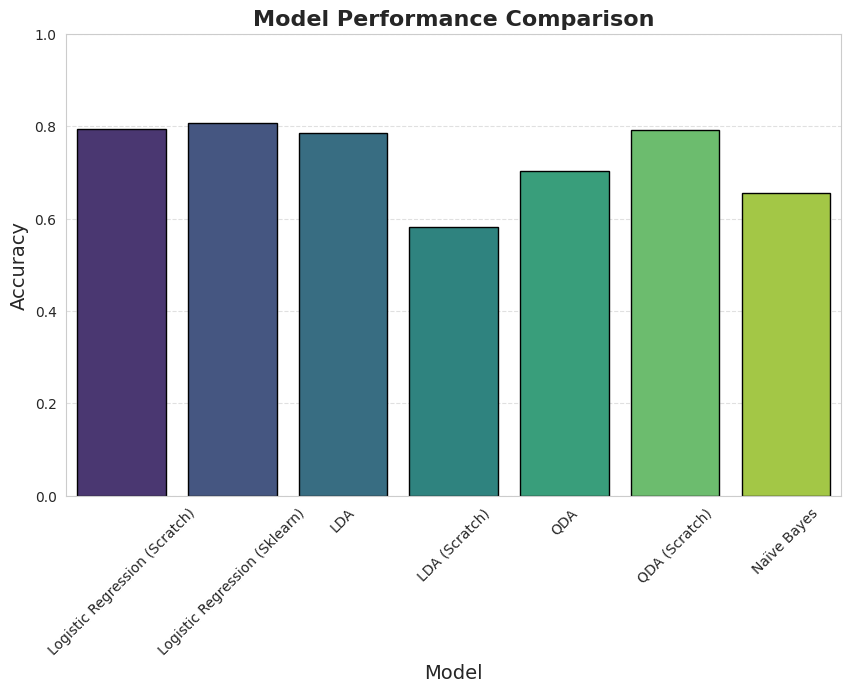

In [18]:
models = ['Logistic Regression (Scratch)', 'Logistic Regression (Sklearn)', 'LDA','LDA (Scratch)', 'QDA','QDA (Scratch)', 'Naïve Bayes']
accuracies = [
    accuracy_score(y_test, y_pred_scratch),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_lda),
    accuracy_score(y_test, y_pred_lda_scratch),
    accuracy_score(y_test, y_pred_qda),
    accuracy_score(y_test, y_pred_qda_scratch),
    accuracy_score(y_test, y_pred_nb)
]

plt.figure(figsize=(10,6))
sns.barplot(x=models, y=accuracies, palette='viridis', edgecolor='black')
plt.ylabel("Accuracy", fontsize=14)
plt.xlabel("Model", fontsize=14)
plt.title("Model Performance Comparison", fontsize=16, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
